In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1,'/Users/sadmin/Documents/MeerFish') # path to MeerFish code
import cosmo
import survey
import model
import fisher

f_tobsloss = 0.5 # fraction of observation time loss

## parameters to include in Fisher forecast:
theta_ids = [\
    #r'$\overline{T}_{\rm HI}$',\
    #r'$b_1$',\
    #r'$b_2$',\
    #r'$b^\phi_1$',\
    #r'$b^\phi_2$',\
    #r'$f$',\
    #r'$\alpha_\perp$',\
    #r'$\alpha_\parallel$',\
    r'$A_{\rm BAO}$',\
    #r'$f_{\rm NL}$'\
    ]

Survey1_arg = 'MK_UHF' # MeerKLASS UHF-band IM survey
Survey2_arg = 'DESI_LRG' # DESI LRG galaxies
t_obs = 800 * (1-f_tobsloss) # total MeerKLASS observation time (with losses then applied)
A_sky = 4000 # original sky area
A_skyX = 3000 # sky area overlapping with DESI galaxies

### Chose whether to explore just monopole, or first three multipoles"
ells = [0]
#ells = [0,2,4]
ell = 0

### Show BAO wiggles detection approach:

/Users/sadmin/Documents/MeerFish/model.py:295: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  d2 = scipy.interpolate.UnivariateSpline(k, derivs[2], k=3, s=1)


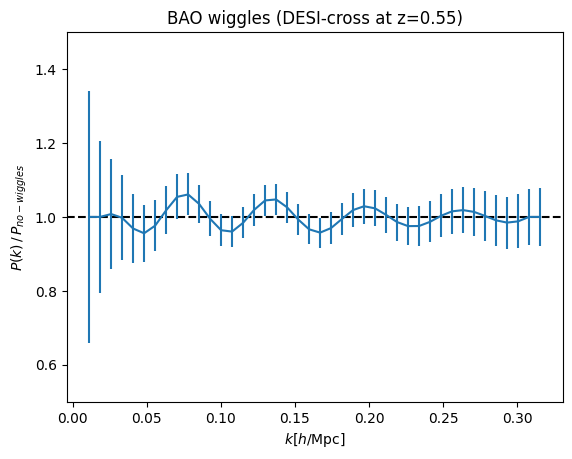

In [2]:
zminzmax = [0.5,0.6]
z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,t_tot=t_obs)
k_fg = 0
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
nuispars = 0,0,0 # ignore nuisance parameters throughout
Pmod = cosmo.MatterPk(z)
k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_skyX,kmax=0.32,Taruya=True)

P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.axhline(1,color='black',ls='--')
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth)
plt.xlabel(r'$k [h/{\rm Mpc}]$')
plt.ylabel(r'$P(k)\,/\,P_{no-wiggles}$')
plt.title('BAO wiggles (DESI-cross at z=%s)'%z) 
plt.ylim(0.5,1.5)
plt.show()

### Produce SNR estimate for two quoted redshifts:

In [3]:
zs = [0.65,0.8] # central redshifts for each bin
deltaz = 0.1 # redshift width for each bin

for i,z_i in enumerate(zs):
    zminzmax = [z_i-deltaz/2,z_i+deltaz/2] # use default
    z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,A_skyX=A_skyX,t_tot=t_obs)
    surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,0
    cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
    Pmod = cosmo.MatterPk(z)

    ### HI auto:
    k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_sky1,kmax=0.32,Taruya=True)
    F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='1')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('HI auto ( z =',z,'):',SNR_BAO)

    ### Cross-correlation:    
    k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_skyX,kmax=0.32,Taruya=True)
    F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='X')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('Cross ( z =',z,'):',SNR_BAO)


HI auto ( z = 0.65 ): 3.389381829528607
Cross ( z = 0.65 ): 3.9462776235972856
HI auto ( z = 0.8 ): 2.853031376545196
Cross ( z = 0.8 ): 3.525146443843414


### Explore impact from a very simple model of signal loss from foreground cleaning:
Here we assume large-scale radial modes i.e. small $k_\parallel$ modes, are damped due to signal loss caused by our foreground cleaning. We damp the power spectrum with the phenomenlogical model given by
$$P_{\rm damped}(k,\mu) = P_{\rm original}(k,\mu)B_{\rm fg}(k,\mu)$$
where 
$$B_{\rm fg}(k,\mu) = 1 - \exp\Bigg[-\Bigg(\frac{k_\parallel}{k_\parallel^{\rm fg}}\Bigg)\Bigg]$$


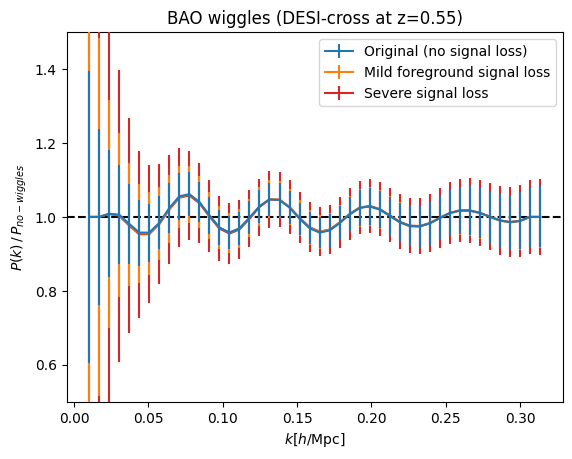

In [4]:
zminzmax = [0.5,0.6]
z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,t_tot=t_obs)
cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
plt.axhline(1,color='black',ls='--')

Pmod = cosmo.MatterPk(z)
k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_sky1,kmax=0.32,Taruya=True)

k_fg = 0 ## no signal loss (original case)
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth,label='Original (no signal loss)',zorder=10)

k_fg = 0.05 ## add some damping to power due to signal loss from foreground cleaning
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth,label='Mild foreground signal loss',color='tab:orange',zorder=9)

k_fg = 0.2 ## add more severe signal loss
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
P_X = model.P_ell(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(ell,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth,label='Severe signal loss',color='tab:red',zorder=8)

plt.xlabel(r'$k [h/{\rm Mpc}]$')
plt.ylabel(r'$P(k)\,/\,P_{no-wiggles}$')
plt.title('BAO wiggles (DESI-cross at z=%s)'%z)
plt.ylim(0.5,1.5)
plt.legend()
plt.show()

### Look at impact on BAO detection SNR:
This makes results dip below 3$\sigma$ - **hence emphasising the importance of controlling systematics**

In [5]:
zs = [0.65,0.8] # central redshifts for each bin
deltaz = 0.1 # redshift width for each bin

k_fg = 0.2

for i,z_i in enumerate(zs):
    zminzmax = [z_i-deltaz/2,z_i+deltaz/2] # use default
    z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,A_skyX=A_skyX,t_tot=t_obs)

    surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
    cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
    Pmod = cosmo.MatterPk(z)

    ### HI auto:
    k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_sky1,kmax=0.32,Taruya=True)
    F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='1')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('HI auto ( z =',z,'):',SNR_BAO)

    ### Cross-correlation:    
    k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_skyX,kmax=0.32,Taruya=True)
    F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='X')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('Cross ( z =',z,'):',SNR_BAO)


HI auto ( z = 0.65 ): 2.4777285176575905
Cross ( z = 0.65 ): 2.202676148787826
HI auto ( z = 0.8 ): 2.0534880827525868
Cross ( z = 0.8 ): 1.8251112676568524


### Explore impact of non-coherent patch calibration:
Currently we assume our $N_{\rm patch}$ patches of $A_{\rm patch}{\sim}300{\rm deg}^2$ observations, combine coherently into a total sky area of $A_{\rm tot} = A_{\rm patch}{\times}N_{\rm patch}$. However, issues with calibration are currently not allowing for this approach and we are restricted to instead doing $N_{\rm patch}$ individual measurements of a power spectrum, and combining their measurements. This slightly changes the analysis and we should instead compute the Fisher matrix for a single $300{\rm deg}^2$ patch, $F_{\rm patch}$, then sum the Fisher matrices from each patch. Assuming each gives equivalent contribution to information this is simply
$$F_{\rm tot} = N_{\rm patch} \times F_{\rm patch}$$

In [6]:
N_patch = 20
t_patch = t_obs/N_patch # total MeerKLASS observation time per patch
A_patch = A_sky/N_patch # sky area per patch
A_patchX = A_skyX/N_patch # overlapping area with DESI galaxies per patch

for i,z_i in enumerate(zs):
    zminzmax = [z_i-deltaz/2,z_i+deltaz/2] # use default
    z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_patch,A_skyX=A_patchX,t_tot=t_patch)
    surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
    cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology
    Pmod = cosmo.MatterPk(z)

    ### HI auto:
    k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_patch,kmax=0.32,Taruya=True)
    F_patch = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='1')
    F_tot = N_patch * F_patch
    C = fisher.FisherInverse(F_tot)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('HI auto ( z =',z,'):',SNR_BAO)

    ### Cross-correlation:    
    k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_patchX,kmax=0.32,Taruya=True)
    F_patch = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='X')
    F_tot = N_patch * F_patch
    C = fisher.FisherInverse(F_tot)
    SNR_BAO = 1/np.sqrt(C[0][0])
    print('Cross ( z =',z,'):',SNR_BAO)

HI auto ( z = 0.65 ): 2.308256540673593
Cross ( z = 0.65 ): 2.0754639225073044
HI auto ( z = 0.8 ): 1.9921552150288002
Cross ( z = 0.8 ): 1.6951751809317936


### Visualise on a grid the impact of observing time and sky area on BAO SNR:

9, 9

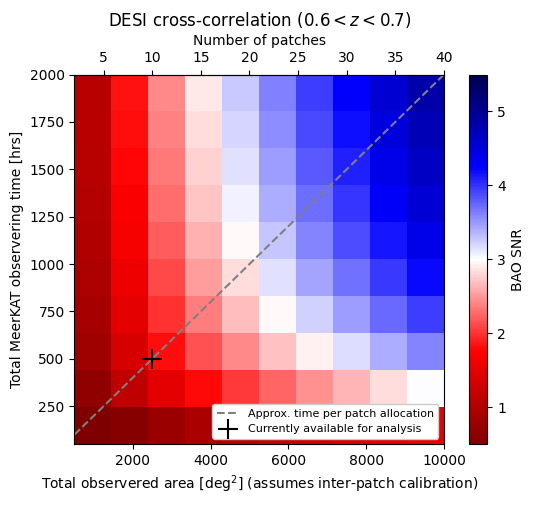

In [8]:
import sys

zminzmax = [0.6,0.7]
A_skyXs = np.linspace(500,10000,10)
t_obss_noloss = np.linspace(50,2000,10) # total MeerKLASS observation times
t_obss = t_obss_noloss * (1-f_tobsloss) # MeerKLASS observation times (with losses then applied)

SNR_BAO = np.zeros((len(A_skyXs),len(t_obss)))
for i,A_sky_i in enumerate(A_skyXs):
    for j,t_obs_j in enumerate(t_obss):
        sys.stdout.write(f"\r{i}, {j}")
        sys.stdout.flush()

        z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,A_skyX=A_sky_i,t_tot=t_obs_j)
        surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
        cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True) # set initial default cosmology

        Pmod = cosmo.MatterPk(z)
        k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_sky_i,kmax=0.32,Taruya=True)
        F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='X')
        C = fisher.FisherInverse(F)
        SNR_BAO[i,j] = 1/np.sqrt(C[0][0])

aspect = (A_skyXs[-1]-A_skyXs[0]) / (t_obss_noloss[-1]-t_obss_noloss[0]) # square aspect pixels
plt.imshow(SNR_BAO.T,origin='lower',extent=[A_skyXs[0],A_skyXs[-1],t_obss_noloss[0],t_obss_noloss[-1]],aspect=aspect,vmin=0.5,vmax=5.5,cmap='seismic_r')
plt.colorbar(label='BAO SNR')

ax = plt.gca()
areaperpatch = 250 # assume area per patch [deg2] to create Number of patches axis:
def area_to_patches(A):
    return A / areaperpatch
def patches_to_area(N):
    return N * areaperpatch
secax = ax.secondary_xaxis('top', functions=(area_to_patches, patches_to_area))
secax.set_xlabel('Number of patches')

## Add current time allocation 1D line:
A_skyX_fid = np.linspace(A_skyXs[0],A_skyXs[-1],100)
t_single_patch = 50 # hours
t_obs_fid = t_single_patch * A_skyX_fid/areaperpatch # approximately we do t_single_patch hrs of observations per 250deg2 patch?
plt.plot(A_skyX_fid,t_obs_fid,color='gray',ls='--',label='Approx. time per patch allocation')
plt.xlim(A_skyXs[0],A_skyXs[-1])
plt.ylim(t_obss_noloss[0],t_obss_noloss[-1])

## Add marker to identify where we are now:
currentnpatch = 10 # how many patches do we currently have ready to analyse 
plt.scatter(currentnpatch*areaperpatch, t_single_patch * currentnpatch,zorder=10,marker='+',s=200,color='black',label='Currently available for analysis')

plt.legend(fontsize=8,framealpha=1,loc='lower right')
plt.xlabel(r'Total observered area [deg$^2$] (assumes inter-patch calibration)')
plt.ylabel('Total MeerKAT observering time [hrs]')
plt.title(r'DESI cross-correlation ($%s{<}z{<}%s$)'%(zminzmax[0],zminzmax[1]))
plt.show()